# Imports #

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

# First checks if all SNIa Have Associated HostGalaxy Coordiantes #

In [2]:
# Load the CSV file
df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")

# Check for missing values in RA_host and Dec_host
missing_ra_host = df['RA_host'].isnull().sum()
missing_dec_host = df['Dec_host'].isnull().sum()

print(f"Missing RA_host: {missing_ra_host}")
print(f"Missing Dec_host: {missing_dec_host}")

# Create a mask for rows with valid RA_host and Dec_host
has_host_coords = df['RA_host'].notnull() & df['Dec_host'].notnull()

# Print how many entries have host coordinates
print(f"Entries with host coordinates: {has_host_coords.sum()}")

# Optionally, filter to just those rows
df_with_hosts = df[has_host_coords]

# Preview a few entries
print(df_with_hosts[['SNID', 'RA_host', 'Dec_host']].head())

Missing RA_host: 926
Missing Dec_host: 926
Entries with host coordinates: 1361
     SNID    RA_host  Dec_host
0  2001ah  167.62646  55.16983
1  2001az  248.62017  76.02972
2  2001da  358.38404   8.11814
3  2001en   21.33637  34.02494
4  2001fe  144.49167  25.49478


# Make a separate .csv file where all informaiton on SNIa with Missing Host Galaxy Coordiantes is Retained #

In [3]:
# Load  input CSV
df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")


# Filter rows where either RA_host or Dec_host is missing
missing_hosts_df = df[df['RA_host'].isnull() | df['Dec_host'].isnull()]

# Save to a new CSV file
output_path = "Pantheon_plus_DESI_match_data/all_redshifts_PVs_missing_host_coords.csv"
missing_hosts_df.to_csv(output_path, index=False)

print(f"Saved {len(missing_hosts_df)} entries with missing host coordinates to '{output_path}'")

Saved 926 entries with missing host coordinates to 'Pantheon_plus_DESI_match_data/all_redshifts_PVs_missing_host_coords.csv'


# Make a Molleweide Projection of the SNIa that do have Host Galaxy Properties Superimposed on DESI #

Has host galaxy info 2287
Does not have host galaxy info 926


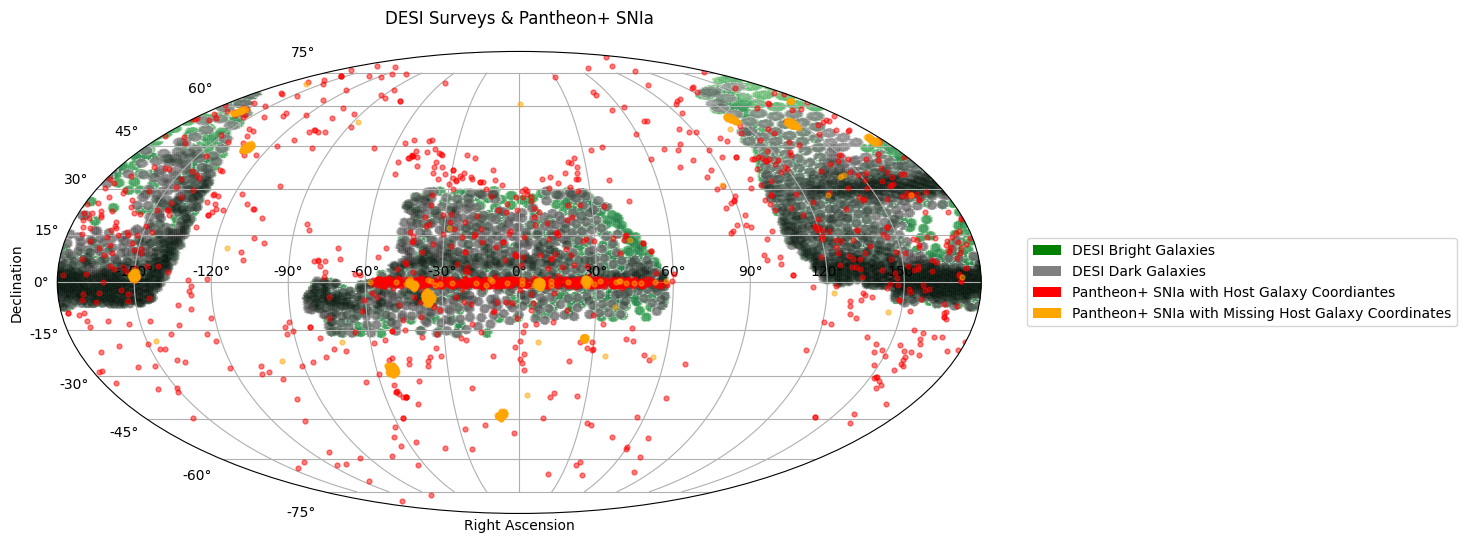

In [26]:
def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

# === Load DESI Bright ===
bright = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load Pantheon+ SNIa w/t Host Galaxy Information Inlcuded ===
# Note: we will be using Host Galaxy Coordiantes Here
snia_df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")
ra_hosts, dec_hosts = prepare_coords(snia_df['RA_host'], snia_df['Dec_host'])

# === Load Pantheon+ SNIa w/t Missing Host Galaxy Informaiton ===
# NOte: we will be using the Actual SNIa coordiantes here.
missing_df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs_missing_host_coords.csv")
ra_snia_missing, dec_snia_missing = prepare_coords(missing_df['RA'], missing_df['Dec'])


# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())


# SNIa with included Host Galaxy Information
# Note: Host Galaxy coordiantes
ax.plot(ra_hosts, dec_hosts, 'r.', markersize=7, alpha=0.5, label='Pantheon+ Host Galaxies')
print("Has host galaxy info " + str(len(ra_hosts)))

# SNIa with missing Host Galaxy Infroamtion
# Note: the SNIa coordaintes are included in there
ax.plot(ra_snia_missing, dec_snia_missing, '.', color = "orange", markersize=7, alpha=0.5, label='Pantheon+ SNIa (No Host Info)')
print("Does not have host galaxy info " + str(len(ra_snia_missing)))



# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='red', label='Pantheon+ SNIa with Host Galaxy Coordiantes', alpha=1),
    Patch(facecolor='orange', label='Pantheon+ SNIa with Missing Host Galaxy Coordinates', alpha=1)
]
# External legend
ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.,
    frameon=True
)
# Plot settings
ax.set_title('DESI Surveys & Pantheon+ SNIa', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

# Same Diagram as Above But With Title and Legend Removed #

Has host galaxy info 2287
Does not have host galaxy info 926


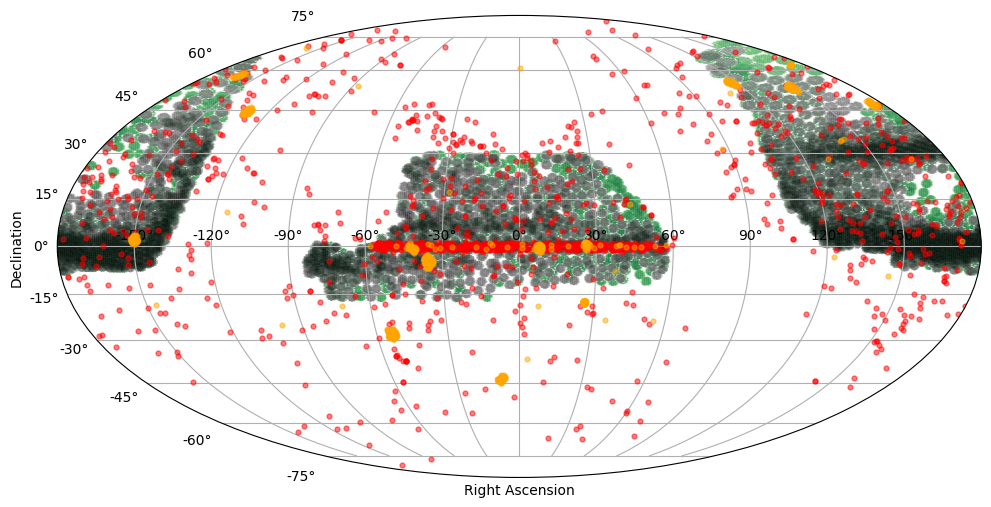

In [5]:
def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

# === Load DESI Bright ===
bright = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load Pantheon+ SNIa w/t Host Galaxy Information Inlcuded ===
# Note: we will be using Host Galaxy Coordiantes Here
snia_df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")
ra_hosts, dec_hosts = prepare_coords(snia_df['RA_host'], snia_df['Dec_host'])

# === Load Pantheon+ SNIa w/t Missing Host Galaxy Informaiton ===
# NOte: we will be using the Actual SNIa coordiantes here.
missing_df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs_missing_host_coords.csv")
ra_snia_missing, dec_snia_missing = prepare_coords(missing_df['RA'], missing_df['Dec'])


# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())


# SNIa with included Host Galaxy Information
# Note: Host Galaxy coordiantes
ax.plot(ra_hosts, dec_hosts, 'r.', markersize=7, alpha=0.5, label='Pantheon+ Host Galaxies')
print("Has host galaxy info " + str(len(ra_hosts)))

# SNIa with missing Host Galaxy Infroamtion
# Note: the SNIa coordaintes are included in there
ax.plot(ra_snia_missing, dec_snia_missing, '.', color = "orange", markersize=7, alpha=0.5, label='Pantheon+ SNIa (No Host Info)')
print("Does not have host galaxy info " + str(len(ra_snia_missing)))



# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='red', label='Pantheon+ SNIa with Host Galaxy Coordiantes', alpha=1),
    Patch(facecolor='orange', label='Pantheon+ SNIa with Missing Host Galaxy Coordinates', alpha=1)
]
# # External legend
# ax.legend(
#     handles=legend_elements,
#     loc='center left',
#     bbox_to_anchor=(1.05, 0.5),
#     borderaxespad=0.,
#     frameon=True
#)

# Plot settings
# ax.set_title('DESI Surveys & Pantheon+ SNIa', pad=20)

ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()

# See If Any of the SNIa Between DES5YR and Pantheon + are the same so as to avoid Double Counting #

In [66]:
# First Lets Look at the Content of the Pantheon+SH0ES .dat File #

# Adjust path to where the file is on your system
file_path = "Pantheon_plus_DESI_match_data/Pantheon+SH0ES.dat"

# Load the .dat file
df = pd.read_csv(file_path, delim_whitespace=True)

# Show first few rows and column names
print(len(df))

print(df[['HOST_RA', 'HOST_DEC']])

1701
      HOST_RA  HOST_DEC
0        -999      -999
1        -999      -999
2        -999      -999
3        -999      -999
4        -999      -999
...       ...       ...
1696     -999      -999
1697     -999      -999
1698     -999      -999
1699     -999      -999
1700     -999      -999

[1701 rows x 2 columns]


/tmp/ipykernel_2193589/1365409496.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True)


In [67]:
print(df.columns)

Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='object')


In [68]:

pv_df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")
shoes_df = pd.read_csv("Pantheon_plus_DESI_match_data/Pantheon+SH0ES.dat", delim_whitespace=True)

# Compare sizes
print(f"Redshifts PV file: {len(pv_df)} entries")
print(f"Pantheon+SHOES.dat: {len(shoes_df)} entries")

# Check how many CIDs from .dat are in the PV file
overlap = shoes_df['CID'].isin(pv_df['SNID']).sum()
print(f"Pantheon+SHOES CIDs in PV file: {overlap}")

# Find CIDs that are only in one of the files
only_in_pv = set(pv_df['SNID']) - set(shoes_df['CID'])
only_in_shoes = set(shoes_df['CID']) - set(pv_df['SNID'])

print(f"Only in PV file: {len(only_in_pv)}")
print(f"Only in SHOES file: {len(only_in_shoes)}")

Redshifts PV file: 2287 entries
Pantheon+SHOES.dat: 1701 entries
Pantheon+SHOES CIDs in PV file: 1676
Only in PV file: 766
Only in SHOES file: 22


/tmp/ipykernel_2193589/4235254233.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  shoes_df = pd.read_csv("Pantheon_plus_DESI_match_data/Pantheon+SH0ES.dat", delim_whitespace=True)


# Lets thake the Pantheon + SH0ES .dat file and turn it into a .csv file #

In [71]:
# Load the .dat file using whitespace delimiter
dat_path = "Pantheon_plus_DESI_match_data/Pantheon+SH0ES.dat"
df = pd.read_csv(dat_path, sep=r'\s+')

# Save as .csv
csv_path = "Pantheon_plus_DESI_match_data/Pantheon+SH0ES.csv"
df.to_csv(csv_path, index=False)

print(f"Converted to CSV and saved to: {csv_path}")

Converted to CSV and saved to: Pantheon_plus_DESI_match_data/Pantheon+SH0ES.csv


# Lets Now Merge available data from all_redshifts.csv to Pantheon+SH0ES.csv #

In [72]:
# Load the Pantheon+SH0ES .csv file
# Note: converted to .csv from original .dat format for easier visualization.
shoes_df = pd.read_csv("Pantheon_plus_DESI_match_data/Pantheon+SH0ES.csv")

# Load the PV data .csv
pv_df = pd.read_csv("Pantheon_plus_DESI_match_data/all_redshifts_PVs.csv")

# Merge: Match CID (from SH0ES) to SNID (from PV)
merged_df = shoes_df.merge(
    pv_df, 
    left_on='CID', 
    right_on='SNID', 
    how='left',
    indicator=True  # ← creates a "merged" collumn that will help further down our journey
)

# Find rows where the merge didn’t find a match in the PV file
pantheon_without_PV_matches = merged_df[merged_df['_merge'] == 'left_only']

pantheon_with_only_PV_matches = merged_df[merged_df['_merge'] == 'both']

# Save merged data to a new CSV 
# Note: this will only contain the rows that got matched. 
merged_path = "Pantheon_plus_DESI_match_data/Pantheon+SH0ES_matched_with_PV.csv"
pantheon_with_only_PV_matches.to_csv(merged_path, index=False)

# Save unmatched entries to another CSV
# Note: this will only contain rows that have unmatched SNIa ID Numbers
unmatched_path = "Pantheon_plus_DESI_match_data/Pantheon+SH0ES_unmatched_to_PVs.csv"
pantheon_without_PV_matches.to_csv(unmatched_path, index=False)

print(f"Merged file saved to: {merged_path}")
print(f"Unmatched entries saved to: {unmatched_path}")

Merged file saved to: Pantheon_plus_DESI_match_data/Pantheon+SH0ES_matched_with_PV.csv
Unmatched entries saved to: Pantheon_plus_DESI_match_data/Pantheon+SH0ES_unmatched_to_PVs.csv


# Now We Retain Information on only the SNIa that have valid host coordinates assicated with them for the Pantheon+ data set that was matched with PV #

In [56]:
# Load the merged Pantheon+SH0ES + PV data
df = pd.read_csv("Pantheon_plus_DESI_match_data/Pantheon+SH0ES_matched_with_PV.csv")

# Keep only rows where both RA_host and Dec_host are NOT null
df_with_hosts = df[df['RA_host'].notna() & df['Dec_host'].notna()]

df_without_hosts = df[df['RA_host'].isna() | df['Dec_host'].isna()]

# Save to a new CSV file
output_file = "Pantheon_plus_DESI_match_data/Pantheon+SHOES_matched_with_PV_has_host_coords.csv"
df_with_hosts.to_csv(output_file, index=False)

output_file_2 = "Pantheon_plus_DESI_match_data/Pantheon+SHOES_matched_with_PV_no_host_coords.csv"
df_without_hosts.to_csv(output_file_2, index=False)


print(f"Filtered file saved to: {output_file}")
print(f"Filtered file saved to: {output_file_2}")


Filtered file saved to: Pantheon_plus_DESI_match_data/Pantheon+SHOES_matched_with_PV_has_host_coords.csv
Filtered file saved to: Pantheon_plus_DESI_match_data/Pantheon+SHOES_matched_with_PV_no_host_coords.csv


# Lets Do Some Plotting #

Has host galaxy info 1003
Has no host galaxy info but matched to pv 674
Has no host galaxy info and no pv matches 25


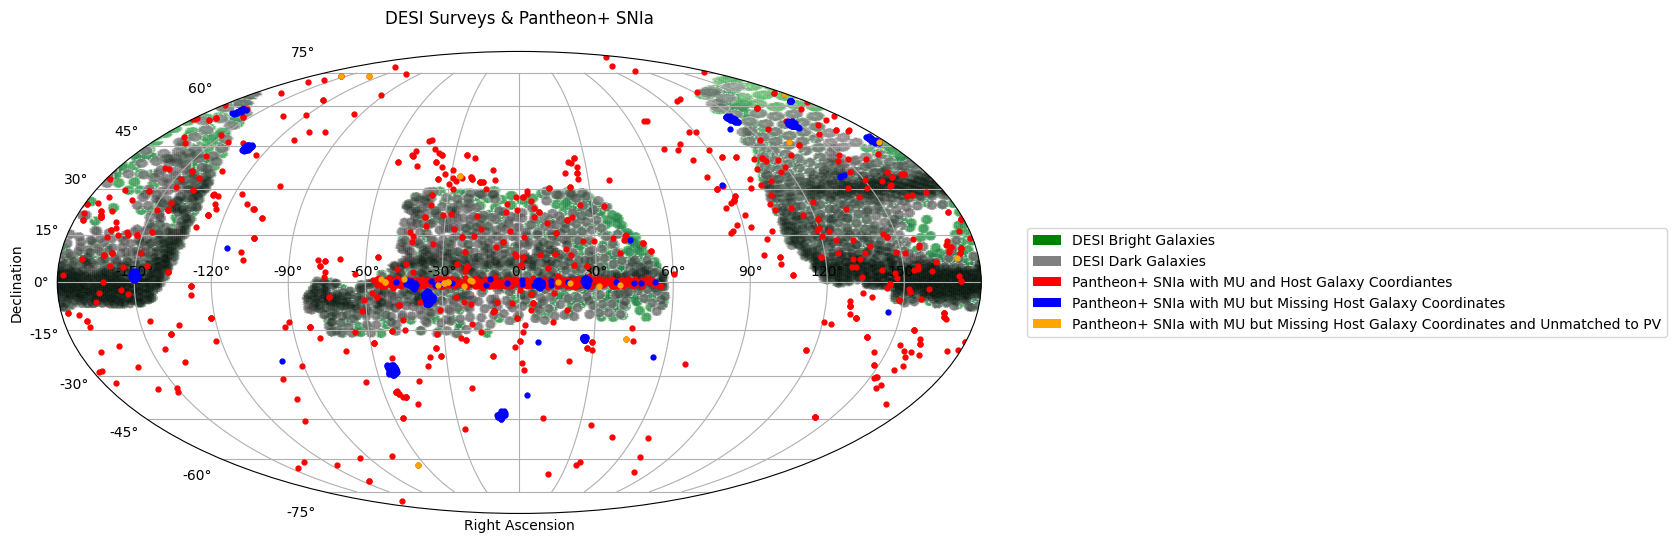

In [92]:
def prepare_coords(ra_deg, dec_deg):
    """Convert RA/DEC from degrees to Mollweide-friendly radians."""
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra = np.remainder(ra + 2*np.pi, 2*np.pi)
    ra[ra > np.pi] -= 2*np.pi
    return -ra, dec

# === Load DESI Bright ===
bright = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata.fits")
ra_bright, dec_bright = prepare_coords(bright['RA'], bright['DEC'])

# === Load DESI Dark ===
dark = Table.read("DES5YR_DESI_match_data/desi_galaxy_metadata_dark.fits")
ra_dark, dec_dark = prepare_coords(dark['RA'], dark['DEC'])

# === Load Pantheon+ SNIa w/t MU and Host Galaxy Coordinates Inlcuded and PV.csv Match ===
# Note: we will be using Host Galaxy Coordiantes Here
snia_df = pd.read_csv("Pantheon_plus_DESI_match_data/Pantheon+SHOES_matched_with_PV_has_host_coords.csv")
ra_hosts, dec_hosts = prepare_coords(snia_df['RA_host'], snia_df['Dec_host'])

# # === Load Pantheon+ SNIa w/t MU but No Host Galaxy Coordinates but PV.csv Match ===
# # Note: we will be using Actual SNIa Coordiantes
snia_df_2 = pd.read_csv("Pantheon_plus_DESI_match_data/Pantheon+SHOES_matched_with_PV_no_host_coords.csv")
ra_pv_nohost, dec_pv_nohost = prepare_coords(snia_df_2['RA_x'], snia_df_2['DEC'])

# # === Load Pantheon+ SNIa w/t MU but No Host Galaxy Coordinates and NO PV.csv Match ===
# # Note: we will be using Actual SNIa Coordiantes
snia_df_3 = pd.read_csv("Pantheon_plus_DESI_match_data/Pantheon+SH0ES_unmatched_to_PVs.csv")
ra_nopv, dec_nopv = prepare_coords(snia_df_3['RA_x'], snia_df_3['DEC'])


# === Plot ===
plt.figure(figsize=(13, 6))
ax = plt.subplot(111, projection='mollweide')

# Flatten arrays for hexbin
x_bright, y_bright = ra_bright.flatten(), dec_bright.flatten()
x_dark, y_dark = ra_dark.flatten(), dec_dark.flatten()

# Hexbin with LogNorm for density contrast

# DESI Bright (density)
hb1 = ax.hexbin(x_bright, y_bright, gridsize=500, cmap='Greens',
                mincnt=1, linewidths=0, norm=LogNorm())

# DESI Dark (density)
hb2 = ax.hexbin(x_dark, y_dark, gridsize=500, cmap='Greys',
                mincnt=1, linewidths=0, norm=LogNorm())


ax.plot(ra_pv_hosts, dec_pv_hosts, 'r.', markersize=7, alpha=1)
print("Has host galaxy info " + str(len(ra_hosts)))


ax.plot(ra_pv_nohost, dec_pv_nohost, '.', color='blue', markersize=7, alpha=1)
print("Has no host galaxy info but matched to pv " + str(len(ra_pv_nohost)))

ax.plot(ra_nopv, dec_nopv, '.', color='orange', markersize=7, alpha=1)
print("Has no host galaxy info and no pv matches " + str(len(ra_nopv)))


# Legend using dummy patches
legend_elements = [
    Patch(facecolor='green', label='DESI Bright Galaxies', alpha=1),
    Patch(facecolor='gray', label='DESI Dark Galaxies', alpha=1),
    Patch(facecolor='red', label='Pantheon+ SNIa with MU and Host Galaxy Coordiantes', alpha=1),
    Patch(facecolor='blue', label='Pantheon+ SNIa with MU but Missing Host Galaxy Coordinates', alpha=1),
    Patch(facecolor='orange', label='Pantheon+ SNIa with MU but Missing Host Galaxy Coordinates and Unmatched to PV', alpha=1)
]
# External legend
ax.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    borderaxespad=0.,
    frameon=True
)
# Plot settings
ax.set_title('DESI Surveys & Pantheon+ SNIa', pad=20)
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')
ax.grid(True)
plt.show()